In [1]:
import sys
from pathlib import Path

def add_src_to_path():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        src = p / "src"
        if src.is_dir():
            sys.path.insert(0, str(src))
            print(f"✅ Added to sys.path: {src}")
            return src
    raise FileNotFoundError(
        f"Could not find a 'src' directory by walking up from {here}.\n"
        f"Current working dir is: {here}"
    )

SRC_DIR = add_src_to_path()
print("First sys.path entry:", sys.path[0])


✅ Added to sys.path: /home/user/src
First sys.path entry: /home/user/src


In [4]:
from collections import OrderedDict
import numpy as np
import torch
from datetime import datetime
from models.LIANet import LIANetLight
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)
data_root = "/home/user/data_shared"


run_dir_available = Path("/home/user/results_shared/fourier_learned_4regions/2026-03-18_19-06-01")
cfg_path_available = run_dir_available / "used_parameters.json"
ckpt_dir_available = run_dir_available / "model_checkpoints" / "checkpoint_Epoch800_Iteration3200000.pt"

model_available = load_model(cfg_path_available, ckpt_dir_available, device)


[ckpt] missing keys: 0 (showing up to 20): []
[ckpt] unexpected keys: 0 (showing up to 20): []


In [3]:
def load_model(cfg_path, ckpt_dir, device):

    with open(cfg_path, "r") as f:
        cfg = json.load(f)
    model_kwargs = cfg.get("model", None)

    model = LIANetLight(
        timestamp_dim=model_kwargs["timestamp_dim"], 
        time_mode="fourier_learned", 
        num_time_frequencies=model_kwargs["num_time_frequencies"], 
        time_input_dim=model_kwargs["time_input_dim"], 
        time_mlp_hidden=model_kwargs["time_mlp_hidden"], 
        levels= model_kwargs["levels"], 
        n_min=model_kwargs["n_min"], 
        growth=model_kwargs["growth"], 
        table_size=model_kwargs["table_size"],
        feat_dim=model_kwargs["feat_dim"], 
        resunet_backbone_size=model_kwargs["resunet_backbone_size"], 
        bilinear=model_kwargs["bilinear"], 
        out_channels=12, 
        preproj_channels=model_kwargs["preproj_channels"],
        hash_vectorized=True,
        num_regions=model_kwargs["num_regions"]
        ).to(device)
    model.eval()

    ckpt = torch.load(str(ckpt_dir), map_location=device)
    state = ckpt["model_state_dict"]

    if any(k.startswith("module.") for k in state.keys()):
            state = {k.replace("module.", "", 1): v for k, v in state.items()}

    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f"[ckpt] missing keys: {len(missing)} (showing up to 20): {missing[:20]}")
    print(f"[ckpt] unexpected keys: {len(unexpected)} (showing up to 20): {unexpected[:20]}")

    return model



In [12]:
y = 7914
x = 10309
reg_idx = 2
query_dt = datetime(2019, 3, 1, 10, 40, 20)
t0 = datetime(2015, 1, 1)
delta_days = float((query_dt - t0).total_seconds() / 86400.0)

xs = torch.tensor([x])
ys = torch.tensor([y])
region_idx = torch.tensor([reg_idx])
delta_days = torch.tensor([delta_days])

pred = model_available(delta_days, xs, ys, region_idx) 

In [13]:
import os
import rasterio
# read the image
region_list= {0: ["T31TFJ"], 1: ["T32ULU"], 2: ["T31TFM"], 3: ["T30UXV"]}



tile_name = region_list[reg_idx][0]
tile_dir = Path(data_root) / tile_name
tile_files = sorted([p for p in tile_dir.iterdir() if p.suffix == ".tif"])

def _parse_tile_datetime(path):
    return datetime.strptime(path.stem, "%Y%m%dT%H%M%S")

img_path = min(
    tile_files,
    key=lambda p: abs((_parse_tile_datetime(p) - query_dt).total_seconds())
)
print(f"Using ground truth image: {img_path.name}")

with rasterio.open(img_path) as src:
    img = src.read()  # shape: (bands, height, width)


# with rasterio.open(img_path) as src:
#     img = src.read()  # shape: (bands, height, width)


def _preprocess_S2(patch):
    patch = patch.astype(np.float32)
    patch = patch - 1000
    patch = patch / 10000
    patch = np.clip(patch, 0, 1)
    return patch


original_image = _preprocess_S2(img)

Using ground truth image: 20190227T104019.tif


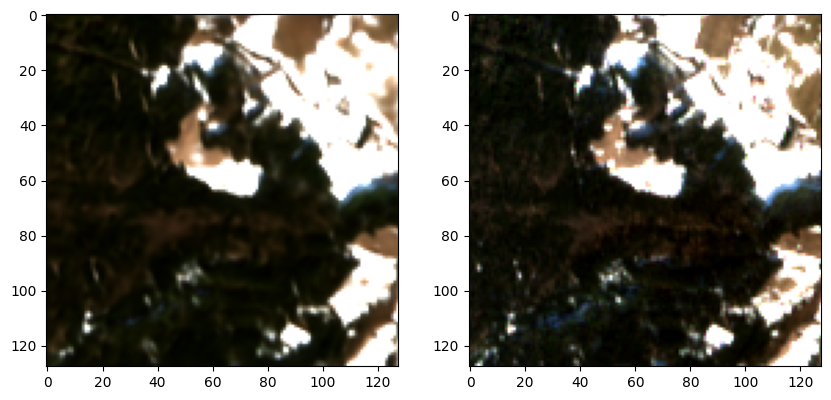

In [14]:
import matplotlib.pyplot as plt

from utils import s2_to_rgb

fig, ax  = plt.subplots(1,2,figsize=(10, 5))
ax[0].imshow(s2_to_rgb(pred.squeeze(0).detach().cpu()))

ax[1].imshow(s2_to_rgb(original_image[:, y:128+y, x:128+x]))   
